In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.9 MB/s eta 0:00:00


In [2]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 20.5 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import time
import json
from google.colab.patches import cv2_imshow # Import cv2_imshow
import cv2
import numpy as np
import math
import os
import matplotlib.pyplot as plt
#import pytesseract
from PIL import Image
plt.style.use('dark_background')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



Loading training YOLO license plate detection and Character Recognition Deep learning models

In [4]:
yolo_model = YOLO("/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/bd_license_plate_detector.pt")
confidence_threshold = 0.25

from tensorflow.keras.models import load_model
from google.colab import drive

ocr_model = load_model("/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/EfficientNetB0_license_plate_v2.keras")

ocr_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,161,460 (50.21 MB)

 Trainable params: 4,372,889 (16.68 MB)

 Non-trainable params: 42,791 (167.16 KB)

 Optimizer params: 8,745,780 (33.36 MB)

Preprocessing and other helper functions


In [5]:
def show_img(title, img, cmap='gray'):
    plt.figure(figsize=(6, 4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show(title, img, cmap='gray', size=(6, 4)):
    plt.figure(figsize=size)
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

def detect_license_plates(image):
    results = yolo_model(image, conf=confidence_threshold)

    detected_plates = []

    for r in results:
        boxes = r.boxes
        if boxes is not None:
            for box in boxes:
                # Get coordinates
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                confidence = box.conf[0].cpu().numpy()

                detected_plates.append({
                    'bbox': [int(x1), int(y1), int(x2), int(y2)],
                    'confidence': float(confidence)
                })

    return detected_plates

def crop_license_plate(image, bbox, padding=10):
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]

    # # Add padding
    # x1 = max(0, x1 - padding)
    # y1 = max(0, y1 - padding)
    # x2 = min(w, x2 + padding)
    # y2 = min(h, y2 + padding)

    # Without padding
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image[y1:y2, x1:x2]

def visualize_results_and_return_best_bbox(image, results):
    vis_image = image.copy()
    best_box = None
    best_det_conf = None

    for result in results:
        bbox = result['bbox']
        det_conf = result['confidence']

        if best_box is None or det_conf > best_det_conf:
            best_box = bbox
            best_det_conf = det_conf

    x1, y1, x2, y2 = best_box

    # Draws bounding box of the best
    # cv2.rectangle(vis_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # cv2.putText(vis_image, str(best_det_conf), (x1, y2+20),
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # cv2_imshow(vis_image)
    return best_box

In [6]:
def unsharp_mask(image, blur_ksize=(5, 5), alpha=1.5, beta=-0.5, gamma=0):
    blurred = cv2.GaussianBlur(image, blur_ksize, 0)

    # Weighted sum: result = alpha*image + beta*blurred + gamma
    sharpened = cv2.addWeighted(image, alpha, blurred, beta, gamma)

    return sharpened

def denoise_bilateral(image):
    return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

def morphological_closing(binary_img):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)
    return closed

def find_contours(dimensions, img, original_for_draw=None):
    # Gets countour
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    lower_width, upper_width, lower_height, upper_height = dimensions

    # Sort by area, keeping top 15
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:20]

    x_cntr_list = []
    target_contours = []
    img_res = []

    # Prepare image to draw bounding boxes on
    draw_img = original_for_draw.copy() if original_for_draw is not None else np.dstack([img]*3)

    for i, cntr in enumerate(cntrs):
        x, y, w, h = cv2.boundingRect(cntr)
        if cv2.contourArea(cntr) > 200 and cv2.contourArea(cntr) < 7000:

          # if lower_width < w < upper_width and lower_height < h < upper_height:
          if True:
              x_cntr_list.append(x)

              char_copy = np.ones((64, 64), dtype=np.uint8) * 255
              char = img[y:y+h, x:x+w]
              char = cv2.resize(char, (62, 62))
              char_copy[2:64, 2:64] = char

              img_res.append(char_copy)

              # Draw box on the visualization image
              cv2.rectangle(draw_img, (x, y), (x+w, y+h), (124,252,0), 2)
              cv2.putText(draw_img, str(i+1), (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (124,252,0), 1)

    # Sorting by x-coord (left to right)
    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res = [img_res[idx] for idx in indices]

    # plt.figure(figsize=(8, 6))
    # plt.imshow(draw_img)
    # plt.title("All Detected Contours on Plate")
    # plt.axis('off')
    # plt.show()

    return img_res

def crop_borders(image, top_pct=0.05, side_pct=0.0125, bottom_pct=0.0125):
    h, w = image.shape[:2]
    top = int(h * top_pct)
    bottom = int(h * (1 - bottom_pct))
    left = int(w * side_pct)
    right = int(w * (1 - side_pct))
    return image[top:bottom, left:right]

In [7]:
def preprocess_image_otsu(img):
    # Step 1: Grayscale

    enhanced = unsharp_mask(img)
    denoised = denoise_bilateral(enhanced)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    # show("Grayscale", gray)

    # Step 2: Contrast enhancement using morphological filters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    top_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    enhanced = cv2.add(gray, top_hat)
    enhanced = cv2.subtract(enhanced, black_hat)
    # show("Contrast Enhanced", enhanced)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # show("Otsu Binary Threshold", binary)

    # Step 4: Erosion + Dilation (noise cleanup)
    binary = cv2.erode(binary, np.ones((2,2), np.uint8), iterations=1)
    binary = cv2.dilate(binary, np.ones((2,2), np.uint8), iterations=1)
    # show("After Erosion + Dilation", binary)

    return binary

def segment_characters_otsu(image):
    # Resize plate and threshold
    img_lp = cv2.resize(image, (333, 335))

    _, binary = cv2.threshold(img_lp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, (3,3))
    binary = cv2.dilate(binary, (3,3))

    # # Add white border
    # binary[0:3,:] = 255
    # binary[:,0:3] = 255
    # binary[332:,:] = 255
    # binary[:,330:] = 255

    dimensions = [binary.shape[0]/6, binary.shape[0]/2, binary.shape[1]/8, 2*binary.shape[1]/3]

    # plt.imshow(binary, cmap='gray')
    # plt.title("Binary Image Before Contours")
    # plt.axis('off')
    # plt.show()

    return find_contours(dimensions, binary, original_for_draw=img_lp) # find_contours now returns two values

In [8]:
def preprocess_image_adap(img):
    # Step 1: Grayscale

    enhanced = unsharp_mask(img)
    denoised = denoise_bilateral(enhanced)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    # show("Grayscale", gray)

    # Step 2: Contrast enhancement using morphological filters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    top_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    enhanced = cv2.add(gray, top_hat)
    enhanced = cv2.subtract(enhanced, black_hat)
    # show("Contrast Enhanced", enhanced)

    # Step 3: Thresholding
    binary = cv2.adaptiveThreshold(
      gray,
      255,
      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # or MEAN_C
      cv2.THRESH_BINARY,
      blockSize=15,  # or 11, 21 (odd numbers only)
      C=4      # tweak this: + makes lighter, - makes darker
    )

    # _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # show("Otsu Binary Threshold", binary)

    # Step 4: Erosion + Dilation (noise cleanup)
    binary = cv2.erode(binary, np.ones((2,2), np.uint8), iterations=1)
    binary = cv2.dilate(binary, np.ones((2,2), np.uint8), iterations=1)
    # show("After Erosion + Dilation", binary)

    return binary

def segment_characters_adap(image):
    # Resize plate and threshold
    img_lp = cv2.resize(image, (333, 335))

    binary = cv2.adaptiveThreshold(
      img_lp,
      255,
      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # or MEAN_C
      cv2.THRESH_BINARY,
      blockSize=15,  # or 11, 21 (odd numbers only)
      C=4        # tweak this: + makes lighter, - makes darker
    )

    # _, binary = cv2.threshold(img_lp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, (3,3))
    binary = cv2.dilate(binary, (3,3))

    # Add white border
    binary[0:3,:] = 255
    binary[:,0:3] = 255
    binary[332:,:] = 255
    binary[:,330:] = 255

    dimensions = [binary.shape[0]/6, binary.shape[0]/2, binary.shape[1]/8, 2*binary.shape[1]/3]

    # plt.imshow(binary, cmap='gray')
    # plt.title("Binary Image Before Contours")
    # plt.axis('off')
    # plt.show()

    return find_contours(dimensions, binary, original_for_draw=img_lp) # find_contours now returns two values

def preprocess_for_model(contour_image):
    # Preprocess a single contour image for inference.

    # Ensuring it is the right size
    if contour_image.shape != (64, 64):
        contour_image = cv2.resize(contour_image, (64, 64))

    # Converting to 3-channel for EfficientNet
    if len(contour_image.shape) == 2:
        img_3ch = np.stack([contour_image, contour_image, img_3ch], axis=-1)
    else:
        img_3ch = contour_image

    # Normalizing to [0, 1] for better model efficiency
    img_3ch = img_3ch.astype(np.float32) / 255.0

    # Add batch dimension
    img_batch = np.expand_dims(img_3ch, axis=0)

    return img_batch

In [9]:
def preprocess_image_adap2(img):
    # Step 1: Grayscale

    enhanced = unsharp_mask(img)
    denoised = denoise_bilateral(enhanced)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    # show("Grayscale", gray)

    # Step 2: Contrast enhancement using morphological filters
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    top_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    enhanced = cv2.add(gray, top_hat)
    enhanced = cv2.subtract(enhanced, black_hat)
    # show("Contrast Enhanced", enhanced)

    # Step 3: Thresholding
    binary = cv2.adaptiveThreshold(
      gray,
      255,
      cv2.ADAPTIVE_THRESH_MEAN_C,  # or MEAN_C
      cv2.THRESH_BINARY,
      blockSize=15,  # or 11, 21 (odd numbers only)
      C=3      # tweak this: + makes lighter, - makes darker
    )

    # _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # show("Otsu Binary Threshold", binary)

    # Step 4: Erosion + Dilation (noise cleanup)
    binary = cv2.erode(binary, np.ones((2,2), np.uint8), iterations=1)
    binary = cv2.dilate(binary, np.ones((2,2), np.uint8), iterations=1)
    # show("After Erosion + Dilation", binary)

    return binary

def segment_characters_adap2(image):
    # Resize plate and threshold
    img_lp = cv2.resize(image, (333, 335))

    binary = cv2.adaptiveThreshold(
      img_lp,
      255,
      cv2.ADAPTIVE_THRESH_MEAN_C,  # or MEAN_C
      cv2.THRESH_BINARY,
      blockSize=15,  # or 11, 21 (odd numbers only)
      C=3        # tweak this: + makes lighter, - makes darker
    )

    # _, binary = cv2.threshold(img_lp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, (3,3))
    binary = cv2.dilate(binary, (3,3))

    # Add white border
    binary[0:3,:] = 255
    binary[:,0:3] = 255
    binary[332:,:] = 255
    binary[:,330:] = 255

    dimensions = [binary.shape[0]/6, binary.shape[0]/2, binary.shape[1]/8, 2*binary.shape[1]/3]

    # plt.imshow(binary, cmap='gray')
    # plt.title("Binary Image Before Contours")
    # plt.axis('off')
    # plt.show()

    return find_contours(dimensions, binary, original_for_draw=img_lp) # find_contours now returns two values

def preprocess_for_model(contour_image):
    # Preprocess a single contour image for inference.

    # Ensuring it is the right size
    if contour_image.shape != (64, 64):
        contour_image = cv2.resize(contour_image, (64, 64))

    # Converting to 3-channel for EfficientNet
    if len(contour_image.shape) == 2:
        img_3ch = np.stack([contour_image, contour_image, img_3ch], axis=-1)
    else:
        img_3ch = contour_image

    # Normalizing to [0, 1] for better model efficiency
    img_3ch = img_3ch.astype(np.float32) / 255.0

    # Add batch dimension
    img_batch = np.expand_dims(img_3ch, axis=0)

    return img_batch

In [10]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'bo',
               'chattro', 'cho', 'dhaka', 'do', 'ga', 'gha', 'ho', 'kho',
               'khulna', 'ko', 'lo', 'maimanshing', 'metro', 'no', 'po',
               'sylhet', 'to', 'tto']

current_region_classes = ['chattro', 'dhaka', 'khulna', 'maimanshing', 'sylhet']

current_letter_class = ['bo', 'cho', 'do', 'ga', 'gha', 'ho', 'kho',
                'ko', 'lo', 'no', 'po', 'to', 'tto']


In [11]:

def find_digits(pred_labels, confidences):
  predicted_digits = []
  for i in range(len(pred_labels)):
    if pred_labels[i].isdigit() and pred_labels[i] not in current_region_classes and pred_labels[i] not in current_letter_class:
      predicted_digits.append([pred_labels[i], i, confidences[i]])

  # sort the predicted digits first based on the confidence
  predicted_digits.sort(key=lambda x: x[2], reverse=True)

  # take the first 6 digits now
  predicted_digits = predicted_digits[:6]

  # sort the predicted digits based on their index
  predicted_digits.sort(key=lambda x: x[1])

  if len(predicted_digits) == 0:
    return [''.join([x[0] for x in predicted_digits]), 0]

  # calculate average confidence and
  avg_conf = sum([x[2] for x in predicted_digits]) / len(predicted_digits)

  # return an array, first index index is a string of all digits and index 1 is avg conf
  return [''.join([x[0] for x in predicted_digits]), avg_conf]


def find_letter(pred_labels, confidences):
  current_letter_class = ['bo', 'cho', 'do', 'ga', 'gha', 'ho', 'kho',
                'ko', 'lo', 'no', 'po', 'to', 'tto']

  # check if the predictions made has any of these as labels, the check happens from the end of the array
  for i in range(len(pred_labels)-1, -1, -1):
    if pred_labels[i] in current_letter_class:
      return [pred_labels[i], confidences[i]]

  return ["", 0]


def find_metro(pred_labels, confidences):
  current_metro_class = ["metro"]
  for i in range(len(pred_labels)):
    # check the region and only return if conf is greater than 80
    if pred_labels[i] in current_metro_class and confidences[i] > 0.80:
      return [pred_labels[i], confidences[i]]

  # if find_region() == "dhaka" or find_region() == "chattro":
  #   return ["metro", 60]
  return ["", 0]


def find_region(pred_labels, confidences):
  current_region_classes = ['chattro', 'dhaka', 'khulna', 'maimanshing', 'sylhet']
  best_conf = 0
  best_region = ""
  for i in range(len(pred_labels)):
    # check the region and only return if conf is greater than 80
    if pred_labels[i] in current_region_classes and confidences[i] > 0.7 and confidences[i] > best_conf:
      best_conf = confidences[i]
      best_region = pred_labels[i]

  # if best region is empty then sort and take the one that is 0.60 above threshhold
  if best_region == "":
    for i in range(len(pred_labels)):
      if confidences[i] > 0.6 and confidences[i] > best_conf and pred_labels[i] in current_region_classes:
        best_conf = confidences[i]
        best_region = pred_labels[i]

  return [best_region, best_conf]

In [12]:
def predict_segmented_characters(segmented_images, show_samples=True, max_samples_to_show=50):
    """
        predicted_classes: List of predicted class indices
        predicted_labels: List of predicted class labels (strings)
        confidences: List of confidence scores
    """

    if len(segmented_images) == 0:
        print("No segmented images provided.")
        return [], [], []

    processed = []
    for img in segmented_images:
        if img.shape != (64, 64):
            img = cv2.resize(img, (64, 64))
        if len(img.shape) == 2:
            img = np.stack([img, img, img], axis=-1)
        img = img.astype(np.float32) / 255.0
        processed.append(img)

    X = np.array(processed)  # Shape: (N, 64, 64, 3)
    predictions = ocr_model.predict(X)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_labels = [class_names[i] for i in predicted_classes]
    confidences = [predictions[i][predicted_classes[i]] for i in range(len(predicted_classes))]

    if show_samples:
        num_samples = min(max_samples_to_show, len(X))

        cols = 5
        rows = (num_samples + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))
        if rows == 1:
            axes = [axes]
        axes = np.array(axes).ravel()

        for i in range(num_samples):
            axes[i].imshow(X[i])
            axes[i].set_title(f"Pred: {predicted_labels[i]}\nConf: {confidences[i]:.2f}")
            axes[i].axis('off')

        # Hide any unused subplots
        for i in range(num_samples, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    return predicted_classes, predicted_labels, confidences

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import restoration

def assess_image_quality(image):
    """Comprehensive image quality assessment"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # 1. Blur detection using Laplacian variance
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 2. Contrast assessment
    contrast = gray.std()

    # 3. Brightness assessment
    brightness = gray.mean()

    # 4. Shadow detection using local standard deviation
    kernel = np.ones((5,5), np.float32) / 25
    local_mean = cv2.filter2D(gray.astype(np.float32), -1, kernel)
    local_variance = cv2.filter2D((gray.astype(np.float32) - local_mean)**2, -1, kernel)
    shadow_metric = np.mean(local_variance)

    # 5. Noise level estimation
    noise_level = cv2.medianBlur(gray, 5)
    noise_metric = np.mean(np.abs(gray.astype(np.float32) - noise_level.astype(np.float32)))

    quality_metrics = {
        'blur_score': laplacian_var,
        'contrast': contrast,
        'brightness': brightness,
        'shadow_metric': shadow_metric,
        'noise_level': noise_metric,
        'is_blurry': laplacian_var < 100,
        'is_low_contrast': contrast < 20,
        'is_too_dark': brightness < 60,
        'is_too_bright': brightness > 200,
        'has_shadows': shadow_metric > 300
    }

    return quality_metrics

def adaptive_deblur(image, quality_metrics):
    if not quality_metrics['is_blurry']:
        return image

    if quality_metrics['blur_score'] < 50:
        psf = np.ones((5, 5)) / 25
        try:
            deblurred = restoration.wiener(
                image, psf, balance=0.1, clip=False, channel_axis=-1
            )
        except TypeError:
            # fallback for older scikit-image
            chans = cv2.split(image)
            out_chans = []
            for ch in chans:
                dc = restoration.wiener(ch, psf, balance=0.1, clip=False)
                out_chans.append(dc)
            deblurred = cv2.merge(out_chans)
        return (np.clip(deblurred, 0, 1) * 255).astype(np.uint8)
    else:
      # mild blur
        gaussian = cv2.GaussianBlur(image, (9, 9), 2.0)
        return cv2.addWeighted(image, 1.5, gaussian, -0.5, 0)

def adaptive_shadow_removal(image, quality_metrics):
    """Remove shadows using adaptive techniques"""
    if not quality_metrics['has_shadows']:
        return image

    # Method 1: Homomorphic filtering
    if len(image.shape) == 3:
        # Convert to LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Apply homomorphic filtering to L channel
        l_log = np.log1p(l.astype(np.float32))
        l_fft = np.fft.fft2(l_log)

        # High-pass filter
        rows, cols = l.shape
        crow, ccol = rows // 2, cols // 2
        mask = np.zeros((rows, cols), np.uint8)
        r = min(crow, ccol) // 3
        cv2.circle(mask, (ccol, crow), r, 1, -1)
        mask = 1 - mask

        l_fft_filtered = l_fft * mask
        l_filtered = np.real(np.fft.ifft2(l_fft_filtered))
        l_filtered = np.expm1(l_filtered)
        l_filtered = np.clip(l_filtered, 0, 255).astype(np.uint8)

        # Reconstructs the image
        lab_filtered = cv2.merge([l_filtered, a, b])
        result = cv2.cvtColor(lab_filtered, cv2.COLOR_LAB2BGR)
    else:
        # Grayscale shadow removal
        result = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(image)

    return result

def multi_scale_retinex(image, scales=[15, 80, 250]):
    """Multi-scale retinex for illumination normalization"""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    retinex = np.zeros_like(image, dtype=np.float32)
    image_float = image.astype(np.float32) + 1.0

    for scale in scales:
        # Gaussian blur
        blurred = cv2.GaussianBlur(image_float, (0, 0), scale)
        # Retinex calculation
        retinex += np.log(image_float) - np.log(blurred + 1e-6)

    retinex = retinex / len(scales)

    # Normalize to 0-255
    retinex = cv2.normalize(retinex, None, 0, 255, cv2.NORM_MINMAX)
    return retinex.astype(np.uint8)

def enhanced_preprocessing_pipeline(image):
    """Complete preprocessing pipeline with quality assessment"""

    # Step 1: Assess image quality
    quality_metrics = assess_image_quality(image)

    # Step 2: Apply appropriate preprocessing
    processed_image = image.copy()

    # Handle shadows and lighting
    if quality_metrics['has_shadows'] or quality_metrics['is_too_dark']:
        processed_image = adaptive_shadow_removal(processed_image, quality_metrics)

    # Apply multi-scale retinex for illumination normalization
    if quality_metrics['is_too_dark'] or quality_metrics['is_too_bright']:
        if len(processed_image.shape) == 3:
            processed_image = cv2.cvtColor(processed_image, cv2.COLOR_BGR2GRAY)
        processed_image = multi_scale_retinex(processed_image)
        processed_image = cv2.cvtColor(processed_image, cv2.COLOR_GRAY2BGR)

    # Enhanced sharpening
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpened = cv2.filter2D(processed_image, -1, kernel)
    processed_image = cv2.addWeighted(processed_image, 0.7, sharpened, 0.3, 0)

    # Noise reduction
    processed_image = cv2.bilateralFilter(processed_image, 9, 75, 75)

    return processed_image, quality_metrics

def hybrid_thresholding(image, quality_metrics):
    """Combine multiple thresholding methods based on image quality"""

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Method 1: OTSU
    _, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Method 2: Adaptive Gaussian
    binary_adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 4
    )

    # Method 3: Adaptive Mean
    binary_adaptive_mean = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, 4
    )

    # Method 4: Multi-Otsu
    try:
        from skimage.filters import threshold_multiotsu
        thresholds = threshold_multiotsu(gray, classes=3)
        binary_multi = np.zeros_like(gray)
        binary_multi[gray > thresholds[0]] = 255
    except:
        binary_multi = binary_otsu

    # Combine methods based on quality metrics
    if quality_metrics['has_shadows']:
        # Use adaptive for shadowy images
        primary_binary = binary_adaptive
        secondary_binary = binary_otsu
    elif quality_metrics['is_low_contrast']:
        # Use multi-otsu for low contrast
        primary_binary = binary_multi
        secondary_binary = binary_adaptive_mean
    else:
        # Use OTSU for normal images
        primary_binary = binary_otsu
        secondary_binary = binary_adaptive

    # Combine using weighted average
    combined_binary = cv2.addWeighted(primary_binary, 0.7, secondary_binary, 0.3, 0)
    _, final_binary = cv2.threshold(combined_binary, 127, 255, cv2.THRESH_BINARY)

    return {
        'otsu': binary_otsu,
        'adaptive_gaussian': binary_adaptive,
        'adaptive_mean': binary_adaptive_mean,
        'multi_otsu': binary_multi,
        'combined': final_binary
    }

# Ensemble preprocessing to get the best, accurate character extraction and prediction using different preprocessing

# Combined threshold preprocessing prediction


In [14]:
def preprocess_and_return_chars_combined(cropped_image):
  quality_metrics = assess_image_quality(cropped_image)

  processed_image, quality_metrics = enhanced_preprocessing_pipeline(cropped_image)

  binary_plates = hybrid_thresholding(processed_image,quality_metrics)

  binary_plate_hybrid = crop_borders(binary_plates['combined'])

  binary_plate_combined = crop_borders(binary_plate_hybrid)
  # closed_img = morphological_closing(binary_plate_combined)
  return segment_characters_otsu(binary_plate_combined)

# multi-otsu prepcoessing prediction

In [15]:
def preprocess_and_return_chars_multi_otsu(cropped_image):
  quality_metrics = assess_image_quality(cropped_image)
  processed_image, quality_metrics = enhanced_preprocessing_pipeline(cropped_image)
  binary_plates = hybrid_thresholding(processed_image,quality_metrics)
  binary_plate_hybrid = crop_borders(binary_plates['multi_otsu'])

  # binary_plate_otsu = preprocess_image_otsu(processed_image)
  binary_plate_combined = crop_borders(binary_plate_hybrid)
  #closed_img = morphological_closing(binary_plate)
  return segment_characters_otsu(binary_plate_combined)

# Enhanced OTsu preprocessing with extra sharpness prediction

In [16]:
def preprocess_and_return_chars_Otsu_enhanced(cropped_image):
  quality_metrics = assess_image_quality(cropped_image)

  processed_image, quality_metrics = enhanced_preprocessing_pipeline(cropped_image)

  binary_plate_otsu_enchanecd = preprocess_image_otsu(processed_image)
  binary_plate_otsu_enchanecd = crop_borders(binary_plate_otsu_enchanecd)
  #closed_img = morphological_closing(binary_plate)
  characters_otsu_enchanced = segment_characters_otsu(binary_plate_otsu_enchanecd)
  return characters_otsu_enchanced

# Normal otsu prediction

In [17]:
def preprocess_and_return_chars_Otsu(cropped_image):
  binary_plate_otsu = preprocess_image_otsu(cropped_image)
  binary_plate_otsu = crop_borders(binary_plate_otsu)
  #closed_img = morphological_closing(binary_plate)
  characters_otsu = segment_characters_otsu(binary_plate_otsu)
  return characters_otsu

# Adapitive threshold preprocessing prediction with Guasian and 4

In [18]:
def preprocess_and_return_chars_adap(cropped_image):
  binary_plate_adap = preprocess_image_adap(cropped_image)
  binary_plate_adap = crop_borders(binary_plate_adap)
  #closed_img = morphological_closing(binary_plate)
  characters_adap = segment_characters_adap(binary_plate_adap)
  return characters_adap

# Adapitive threshold preprocessing prediction with Guasian and 4

In [19]:
def preprocess_and_return_chars_adap2(cropped_image):
  binary_plate_adap2 = preprocess_image_adap2(cropped_image)
  binary_plate_adap2 = crop_borders(binary_plate_adap2)
  #closed_img = morphological_closing(binary_plate)
  characters_adap2 = segment_characters_adap2(binary_plate_adap2)
  return characters_adap2

# Combining prediction results with good confidence for an Output

for output functions -> index 0 is result, index 1 is confidence. avg confidence for the digits

In [20]:
def get_predicted_results_combined(cropped_image):
  characters_combined = preprocess_and_return_chars_combined(cropped_image)
  pred_indices, pred_labels, confidences = predict_segmented_characters(characters_combined, show_samples=False)
  characters_combined_region = find_region(pred_labels, confidences)
  characters_combined_metro = find_metro(pred_labels, confidences)
  characters_combined_letter = find_letter(pred_labels, confidences)
  characters_combined_digits = find_digits(pred_labels, confidences)

  return characters_combined_region, characters_combined_metro, characters_combined_letter, characters_combined_digits

In [21]:
def get_predicted_results_multi_otsu(cropped_image):
  characters_multi_otsu = preprocess_and_return_chars_multi_otsu(cropped_image)

  pred_indices, pred_labels, confidences = predict_segmented_characters(characters_multi_otsu, show_samples=False)

  characters_multi_otsu_region = find_region(pred_labels, confidences)
  characters_multi_otsu_metro = find_metro(pred_labels, confidences)
  characters_multi_otsu_letter = find_letter(pred_labels, confidences)
  characters_multi_otsu_digits = find_digits(pred_labels, confidences)
  return characters_multi_otsu_region, characters_multi_otsu_metro, characters_multi_otsu_letter, characters_multi_otsu_digits

In [22]:
def get_predicted_results_otsu_enhanced(cropped_image):
  characters_otsu_enchanced = preprocess_and_return_chars_Otsu_enhanced(cropped_image)
  pred_indices, pred_labels, confidences = predict_segmented_characters(characters_otsu_enchanced, show_samples=False)

  characters_otsu_enchanced_region = find_region(pred_labels, confidences)
  characters_otsu_enchanced_metro = find_metro(pred_labels, confidences)
  characters_otsu_enchanced_letter = find_letter(pred_labels, confidences)
  characters_otsu_enchanced_digits = find_digits(pred_labels, confidences)
  return characters_otsu_enchanced_region, characters_otsu_enchanced_metro, characters_otsu_enchanced_letter, characters_otsu_enchanced_digits

In [23]:
def get_predicted_results_otsu(cropped_image):
  characters_otsu = preprocess_and_return_chars_Otsu(cropped_image)

  pred_indices, pred_labels, confidences = predict_segmented_characters(characters_otsu, show_samples=False)

  characters_otsu_region = find_region(pred_labels, confidences)
  characters_otsu_metro = find_metro(pred_labels, confidences)
  characters_otsu_letter = find_letter(pred_labels, confidences)
  characters_otsu_digits = find_digits(pred_labels, confidences)
  return characters_otsu_region, characters_otsu_metro, characters_otsu_letter, characters_otsu_digits

In [24]:
def get_predicted_results_adap(cropped_image):
  characters_adap = preprocess_and_return_chars_adap(cropped_image)
  pred_indices, pred_labels, confidences = predict_segmented_characters(characters_adap, show_samples=False)

  characters_adap_region = find_region(pred_labels, confidences)
  characters_adap_metro = find_metro(pred_labels, confidences)
  characters_adap_letter = find_letter(pred_labels, confidences)
  characters_adap_digits = find_digits(pred_labels, confidences)
  return characters_adap_region, characters_adap_metro, characters_adap_letter, characters_adap_digits

In [25]:
def get_predicted_results_adap2(cropped_image):
  characters_adap = preprocess_and_return_chars_adap2(cropped_image)
  pred_indices, pred_labels, confidences = predict_segmented_characters(characters_adap, show_samples=False)

  characters_adap_region = find_region(pred_labels, confidences)
  characters_adap_metro = find_metro(pred_labels, confidences)
  characters_adap_letter = find_letter(pred_labels, confidences)
  characters_adap_digits = find_digits(pred_labels, confidences)
  return characters_adap_region, characters_adap_metro, characters_adap_letter, characters_adap_digits

In [26]:
import easyocr
import re
from difflib import SequenceMatcher

# Initialize EasyOCR reader for Bengali and English
easyocr_reader = easyocr.Reader(['bn'], gpu=False)  # Set gpu=False if no GPU

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

# Easy OCR as a Fallback mechanism

In [27]:
import cv2
import numpy as np
from scipy import ndimage
from skimage import filters, exposure
import matplotlib.pyplot as plt
import easyocr
import os

class LicensePlatePreprocessor:
    """
    License Plate Preprocessing Pipeline based on research paper methodology.
    Implements anisotropic diffusion, image interpolation, histogram equalization,
    and EasyOCR for character recognition as mentioned in the paper.
    """

    def __init__(self, languages=['bn'], gpu=False):
        self.processed_steps = []
        # Initialize EasyOCR reader as mentioned in the paper
        print("Initializing EasyOCR reader...")
        self.ocr_reader = easyocr.Reader(languages, gpu=gpu)
        print("EasyOCR reader initialized successfully!")

    def anisotropic_diffusion(self, image, iterations=15, delta_t=0.14, kappa=20, gamma=0.10):
        """
        Apply anisotropic diffusion for edge-preserving smoothing.

        Parameters:
        - image: Input grayscale image
        - iterations: Number of diffusion iterations
        - delta_t: Time step (0 < delta_t <= 0.25 for stability)
        - kappa: Conduction coefficient (controls edge sensitivity)
        - gamma: Conductance parameter
        """
        # Convert to float for processing
        img = image.astype(np.float64)

        # Initialize output
        diff_img = img.copy()

        for i in range(iterations):
            # Calculate gradients in 4 directions
            nabla_n = np.roll(diff_img, -1, axis=0) - diff_img  # North
            nabla_s = np.roll(diff_img, 1, axis=0) - diff_img   # South
            nabla_e = np.roll(diff_img, -1, axis=1) - diff_img  # East
            nabla_w = np.roll(diff_img, 1, axis=1) - diff_img   # West

            # Calculate conduction coefficients
            c_n = np.exp(-(nabla_n/kappa)**2)
            c_s = np.exp(-(nabla_s/kappa)**2)
            c_e = np.exp(-(nabla_e/kappa)**2)
            c_w = np.exp(-(nabla_w/kappa)**2)

            # Update image
            diff_img += delta_t * (
                c_n * nabla_n + c_s * nabla_s +
                c_e * nabla_e + c_w * nabla_w
            )

        return np.clip(diff_img, 0, 255).astype(np.uint8)

    def image_interpolation(self, image, scale_factor=2.0, method='cubic'):
        """
        Apply image interpolation to enhance resolution and recover details.

        Parameters:
        - image: Input image
        - scale_factor: Scaling factor for interpolation
        - method: Interpolation method ('cubic', 'linear', 'lanczos')
        """
        height, width = image.shape[:2]
        new_height = int(height * scale_factor)
        new_width = int(width * scale_factor)

        # Map interpolation methods
        interpolation_methods = {
            'cubic': cv2.INTER_CUBIC,
            'linear': cv2.INTER_LINEAR,
            'lanczos': cv2.INTER_LANCZOS4
        }

        # Apply interpolation
        interpolated = cv2.resize(
            image,
            (new_width, new_height),
            interpolation=interpolation_methods.get(method, cv2.INTER_CUBIC)
        )

        return interpolated

    def histogram_equalization(self, image, method='clahe'):
        """
        Apply histogram equalization for contrast enhancement.

        Parameters:
        - image: Input grayscale image
        - method: 'standard' for global HE, 'clahe' for adaptive HE
        """
        if method == 'standard':
            # Global histogram equalization
            equalized = cv2.equalizeHist(image)
        else:  # CLAHE (Contrast Limited Adaptive Histogram Equalization)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
            equalized = clahe.apply(image)

        return equalized

    def gaussian_blur(self, image, kernel_size=5, sigma=1.0):
        """
        Apply Gaussian blur for noise reduction.
        """
        return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

    def morphological_operations(self, image, operation='opening', kernel_size=3):
        """
        Apply morphological operations to clean up the image.

        Parameters:
        - image: Binary or grayscale image
        - operation: 'opening', 'closing', 'gradient'
        - kernel_size: Size of morphological kernel
        """
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

        operations = {
            'opening': cv2.MORPH_OPEN,
            'closing': cv2.MORPH_CLOSE,
            'gradient': cv2.MORPH_GRADIENT,
            'erosion': cv2.MORPH_ERODE,
            'dilation': cv2.MORPH_DILATE
        }

        return cv2.morphologyEx(image, operations[operation], kernel)

    def preprocess_image(self, image, config=None):
        """
        Complete preprocessing pipeline for license plate detection.

        Parameters:
        - image: Input image (BGR or grayscale)
        - config: Dictionary with preprocessing parameters
        """
        if config is None:
            config = {
                'anisotropic_diffusion': {
                    'iterations': 15,
                    'delta_t': 0.14,
                    'kappa': 20,
                    'gamma': 0.10
                },
                'interpolation': {
                    'scale_factor': 1.5,
                    'method': 'cubic'
                },
                'histogram_equalization': {
                    'method': 'clahe'
                },
                'gaussian_blur': {
                    'kernel_size': 3,
                    'sigma': 1.0
                }
            }

        # Store original for comparison
        original = image.copy()

        # Convert to grayscale if needed
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()

        self.processed_steps = [('Original', original), ('Grayscale', gray)]

        # Step 1: Anisotropic Diffusion for edge-preserving smoothing
        print("Applying anisotropic diffusion...")
        diffused = self.anisotropic_diffusion(
            gray,
            **config['anisotropic_diffusion']
        )
        self.processed_steps.append(('Anisotropic Diffusion', diffused))

        # Step 2: Image Interpolation for detail recovery
        print("Applying image interpolation...")
        interpolated = self.image_interpolation(
            diffused,
            **config['interpolation']
        )
        self.processed_steps.append(('Interpolated', interpolated))

        # Step 3: Histogram Equalization for contrast enhancement
        print("Applying histogram equalization...")
        equalized = self.histogram_equalization(
            interpolated,
            **config['histogram_equalization']
        )
        self.processed_steps.append(('Histogram Equalized', equalized))

        # Step 4: Optional Gaussian blur for noise reduction
        if config.get('gaussian_blur'):
            print("Applying Gaussian blur...")
            blurred = self.gaussian_blur(
                equalized,
                **config['gaussian_blur']
            )
            self.processed_steps.append(('Gaussian Blurred', blurred))
            final_image = blurred
        else:
            final_image = equalized

        return final_image

    def visualize_preprocessing_steps(self, figsize=(15, 10)):
        """
        Visualize all preprocessing steps in a grid.
        """
        if not self.processed_steps:
            print("No preprocessing steps to visualize. Run preprocess_image first.")
            return

        n_steps = len(self.processed_steps)
        cols = 3
        rows = (n_steps + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        if rows == 1:
            axes = axes.reshape(1, -1)

        for idx, (title, image) in enumerate(self.processed_steps):
            row = idx // cols
            col = idx % cols

            if title == 'Original' and len(image.shape) == 3:
                # Convert BGR to RGB for display
                display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                display_image = image

            axes[row, col].imshow(display_image, cmap='gray' if len(display_image.shape) == 2 else None)
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

        # Hide unused subplots
        for idx in range(n_steps, rows * cols):
            row = idx // cols
            col = idx % cols
            axes[row, col].axis('off')

        plt.tight_layout()
        plt.show()

    def valid_digit_sequence(self, digits):
      if (len(digits) != 7):
        return False
      list_of_bangla_digits = ['০', '১', '২', '৩', '৪', '৫', '৬', '৭', '৮', '৯']

      for dig in digits:
        if dig == '-':
          continue
        if dig not in list_of_bangla_digits:
          return False
      return True

    def extract_license_plate_text(self, image, save_to_file=True, output_file='extracted_text.txt'):
        """
        Extract text from license plate using EasyOCR as mentioned in the research paper.
        Saves the extracted text to a file using UTF-8 encoding as specified in the paper.

        Parameters:
        - image: Preprocessed license plate image
        - save_to_file: Whether to save extracted text to file
        - output_file: Output file path for saving extracted text

        Returns:
        - extracted_text: String containing the recognized license plate text
        - detection_results: Full EasyOCR detection results with confidence scores
        """
        print("Extracting license plate text using EasyOCR...")

        # Use EasyOCR to extract text
        detection_results = self.ocr_reader.readtext(image)

        # Extract text from results
        extracted_texts = []
        confidences = []
        extracted_digits = []

        # we will modify this to get the length 7 digits and modify the digit and return the confidence

        for (bbox, text, confidence) in detection_results:
            if len(text) == 7:
              exact_digits = text
              if exact_digits[2] != "-":
                text_list = list(exact_digits)
                text_list[2] = "-"
                exact_digits = "".join(text_list)

              if (self.valid_digit_sequence(exact_digits)):
                extracted_digits.append(exact_digits)
                extracted_digits.append(confidence)
              print(f"Detected: '{exact_digits}' (Confidence: {confidence:.3f})")

            extracted_texts.append(text)
            confidences.append(confidence)
            print(f"Detected: '{text}' (Confidence: {confidence:.3f})")

        # Combine all detected text
        full_text = ' '.join(extracted_texts)

        return full_text, detection_results, extracted_digits

    def visualize_ocr_results(self, image, detection_results):
        """
        Visualize OCR detection results by drawing bounding boxes and text on the image.
        """
        # Create a copy of the image for visualization
        vis_image = image.copy()
        if len(vis_image.shape) == 2:  # Convert grayscale to BGR for colored annotations
            vis_image = cv2.cvtColor(vis_image, cv2.COLOR_GRAY2BGR)

        # Draw bounding boxes and text
        for (bbox, text, confidence) in detection_results:
            # Convert bbox to integer coordinates
            points = np.array(bbox, dtype=np.int32)

            # Draw bounding box
            cv2.polylines(vis_image, [points], True, (0, 255, 0), 2)

            # Add text label
            label = f"{text} ({confidence:.2f})"
            cv2.putText(vis_image, label, (points[0][0], points[0][1] - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        return vis_image
        """
        Save the final processed image.
        """
        if image is None and self.processed_steps:
            image = self.processed_steps[-1][1]

        if image is not None:
            cv2.imwrite(output_path, image)
            print(f"Processed image saved to: {output_path}")
        else:
            print("No image to save. Run preprocessing first.")

configs = {
        'noisy_image': {
            'anisotropic_diffusion': {
                'iterations': 20,
                'delta_t': 0.12,
                'kappa': 15,
                'gamma': 0.10
            },
            'interpolation': {
                'scale_factor': 1.2,
                'method': 'cubic'
            },
            'histogram_equalization': {
                'method': 'clahe'
            },
            'gaussian_blur': {
                'kernel_size': 3,
                'sigma': 0.8
            }
        },
        'dark_image': {
            'anisotropic_diffusion': {
                'iterations': 10,
                'delta_t': 0.14,
                'kappa': 25,
                'gamma': 0.10
            },
            'interpolation': {
                'scale_factor': 1.5,
                'method': 'lanczos'
            },
            'histogram_equalization': {
                'method': 'clahe'
            }
        },
        'blurred_image': {
            'anisotropic_diffusion': {
                'iterations': 25,
                'delta_t': 0.10,
                'kappa': 30,
                'gamma': 0.15
            },
            'interpolation': {
                'scale_factor': 2.0,
                'method': 'cubic'
            },
            'histogram_equalization': {
                'method': 'standard'
            }
        },
        'bengali_characters': {  # For Bengali character recognition as mentioned in the paper
            'anisotropic_diffusion': {
                'iterations': 15,
                'delta_t': 0.14,
                'kappa': 20,
                'gamma': 0.10
            },
            'interpolation': {
                'scale_factor': 2.0,
                'method': 'cubic'
            },
            'histogram_equalization': {
                'method': 'clahe'
            }
        }
    }

# Combining Results of CNN Prediction and EasyOCR extraction


In [32]:
def find_best_region(all_regions):
    for region in all_regions:
      print(region[0], region[1])

    all_regions = [x for x in all_regions if x is not None and len(x) > 0 and x[0] != ""]
    if len(all_regions) == 0:
        return ""

    print(f"Debug - All regions: {[(x[0], round(x[1], 3)) for x in all_regions]}")

    # Strategy: High confidence first, then frequency-based for medium confidence

    # First, check if any prediction has very high confidence (>0.85)
    high_conf_predictions = [x for x in all_regions if x[1] > 0.85]
    if high_conf_predictions:
        best_region = max(high_conf_predictions, key=lambda x: x[1])
        print(f"Debug - High confidence region selected: {best_region[0]} (conf: {best_region[1]:.3f})")
        return best_region[0]

    # For medium confidence (>0.6), frequency-based approach
    medium_conf_predictions = [x for x in all_regions if x[1] > 0.7]
    if medium_conf_predictions:
        # Convert to tuples for frequency counting
        tuples = [tuple(x) for x in medium_conf_predictions]
        most_frequent = max(set(tuples), key=tuples.count)

        # Additional check: if frequency is same, pick highest confidence
        frequent_regions = [x for x in medium_conf_predictions if x[0] == most_frequent[0]]
        best_frequent = max(frequent_regions, key=lambda x: x[1])

        print(f"Debug - Medium confidence region selected: {best_frequent[0]} (conf: {best_frequent[1]:.3f}, count: {tuples.count(most_frequent)})")
        return best_frequent[0]

    # Fallback to highest confidence if all are low confidence
    if len(all_regions) > 0:
        best_region = max(all_regions, key=lambda x: x[1])
        print(f"Debug - Low confidence fallback region: {best_region[0]} (conf: {best_region[1]:.3f})")
        return best_region[0]

    return ""


def find_best_metro(all_metro):
    all_metro = [x for x in all_metro if x is not None and len(x) > 0 and x[0] != ""]
    if len(all_metro) == 0:
        return ""

    print(f"Debug - All metro: {[(x[0], round(x[1], 3)) for x in all_metro]}")

    # Strategy: High confidence first, then frequency-based for medium confidence

    # First, check if any prediction has very high confidence (>0.8)
    high_conf_predictions = [x for x in all_metro if x[1] > 0.8]
    if high_conf_predictions:
        best_metro = max(high_conf_predictions, key=lambda x: x[1])
        print(f"Debug - High confidence metro selected: {best_metro[0]} (conf: {best_metro[1]:.3f})")
        return best_metro[0]

    # For medium confidence (>0.5), use frequency-based approach
    medium_conf_predictions = [x for x in all_metro if x[1] > 0.5]
    if medium_conf_predictions:
        # Convert to tuples for frequency counting
        tuples = [tuple(x) for x in medium_conf_predictions]
        most_frequent = max(set(tuples), key=tuples.count)

        # Additional check: if frequency is same, pick highest confidence
        frequent_metros = [x for x in medium_conf_predictions if x[0] == most_frequent[0]]
        best_frequent = max(frequent_metros, key=lambda x: x[1])

        print(f"Debug - Medium confidence metro selected: {best_frequent[0]} (conf: {best_frequent[1]:.3f}, count: {tuples.count(most_frequent)})")
        return best_frequent[0]

    # For metro, lets be be more lenient - check if any prediction exists with >0.3 confidence
    low_conf_predictions = [x for x in all_metro if x[1] > 0.3]
    if low_conf_predictions:
        # Use frequency approach even for low confidence
        tuples = [tuple(x) for x in low_conf_predictions]
        most_frequent = max(set(tuples), key=tuples.count)

        # If multiple predictions agree on metro, even with low confidence, trust it
        if tuples.count(most_frequent) > 1:
            frequent_metros = [x for x in low_conf_predictions if x[0] == most_frequent[0]]
            best_frequent = max(frequent_metros, key=lambda x: x[1])
            print(f"Debug - Low confidence but frequent metro selected: {best_frequent[0]} (conf: {best_frequent[1]:.3f}, count: {tuples.count(most_frequent)})")
            return best_frequent[0]

    print("Debug - No metro detected with sufficient confidence")
    return ""


def find_best_letter(all_letters):
    all_letters = [x for x in all_letters if x is not None and len(x) > 0 and x[0] != ""]
    if len(all_letters) == 0:
        return ""

    print(f"Debug - All letters: {[(x[0], round(x[1], 3)) for x in all_letters]}")

    # First, check if any prediction has very high confidence (>0.8)
    high_conf_predictions = [x for x in all_letters if x[1] > 0.85]
    if high_conf_predictions:
        best_letter = max(high_conf_predictions, key=lambda x: x[1])
        print(f"Debug - High confidence letter selected: {best_letter[0]} (conf: {best_letter[1]:.3f})")
        return best_letter[0]

    # For medium confidence (>0.4), use smart frequency + confidence approach
    medium_conf_predictions = [x for x in all_letters if x[1] > 0.7]
    if medium_conf_predictions:
        # Group by letter and calculate frequency + confidence stats
        letter_groups = {}
        for letter_str, conf in medium_conf_predictions:
            if letter_str not in letter_groups:
                letter_groups[letter_str] = []
            letter_groups[letter_str].append(float(conf))

        print(f"Debug - Letter groups: {letter_groups}")

        # Calculate scores for each letter
        letter_scores = {}
        max_frequency = max(len(confs) for confs in letter_groups.values())

        for letter_str, confs in letter_groups.items():
            frequency = len(confs)
            avg_conf = sum(confs) / len(confs)
            max_conf = max(confs)

            # If multiple letters have same max frequency, use confidence
            # Otherwise, frequency takes precedence
            if frequency == max_frequency:
                # Same frequency, use confidence-based scoring
                score = avg_conf * 10 + max_conf
            else:
                # Different frequency, heavily weight frequency
                score = frequency * 100 + avg_conf * 10 + max_conf

            letter_scores[letter_str] = {
                'score': score,
                'frequency': frequency,
                'avg_conf': avg_conf,
                'max_conf': max_conf
            }

            print(f"Debug - {letter_str}: freq={frequency}, avg_conf={avg_conf:.3f}, max_conf={max_conf:.3f}, score={score:.2f}")

        # returns the letter with the highastr scotre
        best_letter_str = max(letter_scores, key=lambda x: letter_scores[x]['score'])
        best_stats = letter_scores[best_letter_str]

        print(f"Debug - Medium confidence letter selected: {best_letter_str} (freq: {best_stats['frequency']}, conf: {best_stats['max_conf']:.3f})")
        return best_letter_str

    low_conf_predictions = [x for x in all_letters if x[1] > 0.4]
    if low_conf_predictions:
        # Use frequency approach even for low confidence
        tuples = [tuple(x) for x in low_conf_predictions]
        most_frequent = max(set(tuples), key=tuples.count)

        # If multiple predictions agree on metro, even with low confidence, trust it
        if tuples.count(most_frequent) > 1:
            frequent_metros = [x for x in low_conf_predictions if x[0] == most_frequent[0]]
            best_frequent = max(frequent_metros, key=lambda x: x[1])
            print(f"Debug - Low confidence but frequent metro selected: {best_frequent[0]} (conf: {best_frequent[1]:.3f}, count: {tuples.count(most_frequent)})")
            return best_frequent[0]

    # Fallback to highest confidence if all are low
    best_letter = max(all_letters, key=lambda x: x[1])
    print(f"Debug - Low confidence fallback letter: {best_letter[0]} (conf: {best_letter[1]:.3f})")
    return best_letter[0]


def find_best_digits(all_digits):
    all_digits = [x for x in all_digits if x is not None and len(x) > 1 and len(x[0]) >= 6 and x[0] not in current_letter_class and x[0] not in current_region_classes]
    if len(all_digits) == 0:
        return "",0

    print(f"Debug - All digits: {[(x[0], round(x[1], 3)) for x in all_digits]}")

    # Strategy: For high confidence (>0.85), prioritize frequency over small confidence differences

    # First, check if we have high confidence predictions (>0.85)
    high_conf_predictions = [x for x in all_digits if x[1] >= 0.82]
    if high_conf_predictions:
        print(f"Debug - Found {len(high_conf_predictions)} high confidence predictions")

        # Group by digit string and calculate frequency + confidence stats
        digit_groups = {}
        for digit_str, conf in high_conf_predictions:
            if digit_str not in digit_groups:
                digit_groups[digit_str] = []
            digit_groups[digit_str].append(float(conf))

        # Calculate scores: frequency is primary, then average confidence
        digit_scores = {}
        for digit_str, confs in digit_groups.items():
            frequency = len(confs)
            avg_conf = sum(confs) / len(confs)
            max_conf = max(confs)

            # Score = frequency * 100 + average_confidence * 10 + max_confidence
            # This heavily weights frequency while still considering confidence
            score = frequency * 100 + avg_conf * 10 + max_conf
            digit_scores[digit_str] = {
                'score': score,
                'frequency': frequency,
                'avg_conf': avg_conf,
                'max_conf': max_conf
            }

            print(f"Debug - {digit_str}: freq={frequency}, avg_conf={avg_conf:.3f}, max_conf={max_conf:.3f}, score={score:.2f}")

        best_digit_str = max(digit_scores, key=lambda x: digit_scores[x]['score'])
        best_stats = digit_scores[best_digit_str]

        print(f"Debug - High confidence digits selected: {best_digit_str} (freq: {best_stats['frequency']}, avg_conf: {best_stats['avg_conf']:.3f})")
        return best_digit_str, best_stats['max_conf']

    # For medium-high confidence (>0.7), use frequency-based approach
    medium_conf_predictions = [x for x in all_digits if x[1] > 0.7]
    if medium_conf_predictions:

        tuples = [tuple(x) for x in medium_conf_predictions]
        most_frequent = max(set(tuples), key=tuples.count)

        frequent_digits = [x for x in medium_conf_predictions if x[0] == most_frequent[0]]
        best_frequent = max(frequent_digits, key=lambda x: x[1])

        print(f"Debug - Medium-high confidence digits selected: {best_frequent[0]} (conf: {best_frequent[1]:.3f}, count: {tuples.count(most_frequent)})")
        return best_frequent[0], best_frequent[1]

    # For digits, if no high confidence predictions, we have to be more cautious
    if len(all_digits) > 0:
        best_digits = max(all_digits, key=lambda x: x[1])

        if best_digits[1] > 0.5:
            print(f"Debug - Moderate confidence digits selected: {best_digits[0]} (conf: {best_digits[1]:.3f})")
            return best_digits[0], best_digits[1]
        else:
            print(f"Debug - All digit predictions have low confidence, returning empty")
            return "", 0

    return "", 0

def translate_metro(metro):
  if metro != "":
    return "মেট্রো"
  return ""

def translate_region(region):
    region_dict = {
        "dhaka": "ঢাকা",
        "khulna": "খুলনা",
        "sylhet": "সিলেট",
        "chattro": "চট্ট",
        "barishal": "বরিশাল",
        "rangpur": "রংপুর",
        "rajshahi": "রাজশাহী",
        "mymensingh": "ময়মনসিংহ",
        "gazipur": "গাজীপুর",
        "gajipur": "গজীপর",

        # Additional districts
        "cumilla": "কুমিল্লা",
        "narayanganj": "নারায়ণগঞ্জ",
        "tangail": "টাঙ্গাইল",
        "faridpur": "ফরিদপুর",
        "dinajpur": "দিনাজপুর",
        "pabna": "পাবনা",
        "bogura": "বগুড়া",
        "jashore": "যশোর",
        "chandpur": "চাঁদপুর",
        "feni": "ফেনী",
        "coxbazar": "কক্সবাজার",
        "magura": "মাগুরা",
        "kushtia": "কুষ্টিয়া",
        "jhenaidah": "ঝিনাইদহ",
        "madaripur": "মাদারীপুর",
        "gopalganj": "গোপালগঞ্জ",
        "sirajganj": "সিরাজগঞ্জ",
        "naogaon": "নওগাঁ",
        "natore": "নাটোর",
        "kurigram": "কুড়িগ্রাম",
        "gaibandha": "গাইবান্ধা",
        "lalmonirhat": "লালমনিরহাট",
        "thakurgaon": "ঠাকুরগাঁও",
        "panchagarh": "পঞ্চগড়"
    }

    if region != "" and region in region_dict:
        return region_dict[region]

    return region if region != "" else ""

def translate_letter(letter):
    letter_dict = {
        "bo": "ব",
        "cho": "চ",
        "do": "ঢ",
        "ga": "গ",
        "gha": "ঘ",
        "ho": "হ",
        "kho": "খ",
        "ko": "ক",
        "lo": "ল",
        "no": "ন",
        "po": "প",
        "to": "ট",
        "tto": "ঠ",
        "jho": "ঝ",

        # Additional letters that were missing
        "jo": "জ",
        "mo": "ম",
        "ro": "র",
        "so": "স",
        "tho": "থ",
    }

    if letter != "" and letter in letter_dict:
        return letter_dict[letter]
    return letter if letter != "" else ""

def parse_easyocr_text(extracted_texts):
    # Bengali region patterns (more comprehensive with partial matches)
    region_patterns = {
        # Divisions
        r'ঢাকা|dhaka|ঢাক|dhak': 'dhaka',
        r'খুলনা|khulna|খুল|খু|khul': 'khulna',
        r'সিলেট|sylhet|সিল|syl': 'sylhet',
        r'চট্টগ্রাম|চট্ট|chattogram|chattro|chat|ctg': 'chattro',
        r'ময়মনসিংহ|mymensingh|ময়ম|মাই|maim|mym': 'mymensingh',
        r'বরিশাল|barishal|বরি|bari': 'barishal',
        r'রংপুর|rangpur|রং|rang': 'rangpur',
        r'রাজশাহী|rajshahi|রাজ|raj': 'rajshahi',

        # Major districts (commonly on plates)
        r'কুমিল্লা|কুমিল|কুমি|cumilla|comilla|cumi': 'cumilla',
        r'গাজীপুর|gazipur|গাজী|গাজ|gazi': 'gazipur',
        r'নারায়ণগঞ্জ|narayanganj|নারায়ণ|নারা|nara': 'narayanganj',
        r'টাঙ্গাইল|tangail|টাঙ্গ|tan': 'tangail',
        r'ফরিদপুর|faridpur|ফরি|ফরিদ|fari': 'faridpur',
        r'দিনাজপুর|dinajpur|দিনা|দিন|din': 'dinajpur',
        r'পাবনা|pabna|পাব|পা|pab': 'pabna',
        r'বগুড়া|bogura|বগু|বগ|bog': 'bogura',
        r'যশোর|jashore|jeshore|যশ|যশো|jas': 'jashore',
        r'চাঁদপুর|chandpur|চাঁদ|চান|chan': 'chandpur',
        r'ফেনী|feni|ফে|ফেন': 'feni',
        r'কক্সবাজার|cox|coxbazar|কক্স|কক্সবাজার': 'coxbazar',
        r'মাগুরা|magura|মাগু|মা|mag': 'magura',
        r'কুষ্টিয়া|kushtia|কু|কুষ্টি|kus': 'kushtia',
        r'ঝিনাইদহ|jhenaidah|ঝি|ঝিনাই|jhen': 'jhenaidah',
        r'মাদারীপুর|madaripur|মাদারী|মাদা|mada': 'madaripur',
        r'গোপালগঞ্জ|gopalganj|গোপা|গোপাল|gopal': 'gopalganj',
        r'সিরাজগঞ্জ|sirajganj|সিরা|সিরা|siraj': 'sirajganj',
        r'নওগাঁ|naogaon|নও|নওগা|nao': 'naogaon',
        r'নাটোর|natore|নাট|না|nat': 'natore',
        r'কুড়িগ্রাম|kurigram|কুড়ি|কুড়ি|kuri': 'kurigram',
        r'গাইবান্ধা|gaibandha|গাই|গাইবা|gai': 'gaibandha',
        r'গজীপর': 'gajipur',
        r'লালমনিরহাট|lalmonirhat|লাল|লালমনি|lal': 'lalmonirhat',
        r'ঠাকুরগাঁও|thakurgaon|ঠাকুর|ঠাক|thak': 'thakurgaon',
        r'পঞ্চগড়|panchagarh|পঞ্চ|পঞ|panch': 'panchagarh'
    }

    # Letter patterns (Bengali characters) - more comprehensive
    letter_patterns = {
        'ব': 'bo', 'চ': 'cho', 'ঢ': 'do', 'গ': 'ga', 'ঘ': 'gha',
        'হ': 'ho', 'খ': 'kho', 'ক': 'ko', 'ল': 'lo', 'ন': 'no',
        'প': 'po', 'ট': 'to', 'ঠ': 'tto', 'জ': 'jo', 'ম': 'mo',
        'র': 'ro', 'স': 'so', 'থ': 'tho',
    }

    result = {
        "region": "",
        "letter": ""
    }

    # Handle both string and list inputs
    if isinstance(extracted_texts, str):
        text_list = [extracted_texts]
    elif isinstance(extracted_texts, list):
        text_list = extracted_texts
    else:
        return result

    # Combine all extracted texts into one string for processing
    combined_text = " ".join(text_list).lower()

    # Clean the text - remove extra spaces and normalize
    combined_text = re.sub(r'\s+', ' ', combined_text).strip()

    # Extract region
    for pattern, region_code in region_patterns.items():
        if re.search(pattern, combined_text, re.IGNORECASE):
            result["region"] = region_code
            break

    # Extract letter - look for Bengali characters that appear after a dash or at the end
    # Pattern 1: Look for letter after dash (with or without spaces)
    dash_pattern = r'[-–—]\s*([া-ৃঅ-ঔ])'
    dash_match = re.search(dash_pattern, combined_text)

    if dash_match:
        found_letter = dash_match.group(1)
        result["letter"] = letter_patterns.get(found_letter, found_letter)
    else:
        # Pattern 2: If no dash found, look for isolated Bengali letters
        # This handles cases where OCR misses the dash
        bengali_letters = re.findall(r'[া-ৃঅ-ঔ]', combined_text)

        if bengali_letters:
            # Take the last Bengali letter found (usually the letter code)
            # Skip if it's part of a region name
            for letter in reversed(bengali_letters):
                # Check if this letter is not part of any region pattern
                is_part_of_region = False
                for region_pattern in region_patterns.keys():
                    if letter in region_pattern:
                        is_part_of_region = True
                        break

                if not is_part_of_region:
                    result["letter"] = letter_patterns.get(letter, letter)
                    break

    return result

def translate_digits(digits):
  # digits are in the form of 123456, so have to loop through and translate to bangla
  digit_dict = {
      "0": "০",
      "1": "১",
      "2": "২",
      "3": "৩",
      "4": "৪",
      "5": "৫",
      "6": "৬",
      "7": "৭",
      "8": "৮",
      "9": "৯"
  }

  if digits != "":
    for digit in digits:
      if digit in digit_dict:
        digits = digits.replace(digit, digit_dict[digit])
    return digits

  return ""

def find_check_easyocr_match_with_cnn(all_digits, ocr_digits):
    all_digits = [x for x in all_digits if x is not None and len(x) > 1 and len(x[0]) >= 6 and x[0] not in current_letter_class and x[0] not in current_region_classes]
    if len(all_digits) == 0:
        return ""

    # there are conditions where ocr_digits will be in formats of 12-3456 or 123456
    # but digits from cnn will be in 123456 format only
    # either way for ocr digits we will need to remove 2nd index string to compare
    ocr_digit_list = list(ocr_digits)
    # popping 2nd index
    if len(ocr_digit_list) > 2:
      ocr_digit_list.pop(2)
      ocr_digits = "".join(ocr_digit_list)

    for digit in all_digits:
        if digit[0] == ocr_digits:
            return digit[0]
    return ""

def final_result():
  characters_combined_region, characters_combined_metro, characters_combined_letter, characters_combined_digits = get_predicted_results_combined(cropped_image)
  characters_multi_otsu_region, characters_multi_otsu_metro, characters_multi_otsu_letter, characters_multi_otsu_digits = get_predicted_results_multi_otsu(cropped_image)
  characters_otsu_region, characters_otsu_metro, characters_otsu_letter, characters_otsu_digits = get_predicted_results_otsu(cropped_image)
  characters_adap_region, characters_adap_metro, characters_adap_letter, characters_adap_digits = get_predicted_results_adap(cropped_image)
  characters_otsu_enchanced_region, characters_otsu_enchanced_metro, characters_otsu_enchanced_letter, characters_otsu_enchanced_digits = get_predicted_results_otsu_enhanced(cropped_image)
  characters_adap2_region, characters_adap2_metro, characters_adap2_letter, characters_adap2_digits = get_predicted_results_adap2(cropped_image)

  preprocessor = LicensePlatePreprocessor()
  processed_img = preprocessor.preprocess_image(cropped_image, configs['bengali_characters'])
  easyocr_text, results, easyocr_digits = preprocessor.extract_license_plate_text(processed_img)

  all_regions = [characters_otsu_region, characters_adap_region, characters_adap2_region]
  all_metro = [characters_otsu_metro, characters_adap_metro, characters_adap2_metro]
  all_letters = [characters_otsu_letter, characters_adap_letter, characters_adap2_letter]
  all_digits = [characters_otsu_digits, characters_adap_digits, characters_adap2_digits,]
  best_region = find_best_region(all_regions)
  best_metro = find_best_metro(all_metro)
  best_letter = find_best_letter(all_letters)

  # for digits, we will take the one with higher conf between easyocr and cnn
  best_digits, best_digits_conf = find_best_digits(all_digits)

  if (len(easyocr_digits)>0):
    print("easyocr_digits to float", float(easyocr_digits[1]))

  print("best_digits_conf: ", best_digits_conf)
  if len(easyocr_digits) == 2 and (best_digits_conf < float(easyocr_digits[1]) or len(easyocr_digits[0]) == 7):
    best_digits = easyocr_digits[0]
  else:
    best_digits = translate_digits(best_digits)

  parsed_texts = parse_easyocr_text(easyocr_text)
  parsed_region = parsed_texts['region']

  if (parsed_region != "" and best_region != parsed_region):
    best_region = parsed_region

  print(easyocr_text)
  print(parse_easyocr_text(easyocr_text))

  return f"{translate_region(best_region)} {translate_metro(best_metro)} - {translate_letter(best_letter)} \n {(best_digits)}"

# Detecting the License plate region using YOLO

In [101]:
image_path = "/content/drive/MyDrive/datasets/char_license_plates/Vehicle1579.jpg"
image = cv2.imread(str(image_path))
results = detect_license_plates(image)
bbox = visualize_results_and_return_best_bbox(image, results)
cropped_image = crop_license_plate(image, bbox)


0: 256x640 1 license_plate, 750.6ms
Speed: 3.1ms preprocess, 750.6ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 640)


# Combining multiple prepcoressing CNN prediction result and validating using easyOCR detection texts

In [102]:
final_text = final_result()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step


Initializing EasyOCR reader...
EasyOCR reader initialized successfully!
Applying anisotropic diffusion...
Applying image interpolation...
Applying histogram equalization...
Extracting license plate text using EasyOCR...
Detected: 'ঢাকা' (Confidence: 0.669)
Detected: 'মেট্রো-স' (Confidence: 0.574)
Detected: '0' (Confidence: 0.043)
Detected: '০২৪৫' (Confidence: 0.798)
Detected: '১' (Confidence: 0.984)
dhaka 0.87276185
 0
dhaka 0.9333487
Debug - All regions: [('dhaka', np.float32(0.873)), ('dhaka', np.float32(0.933))]
Debug - High confidence region selected: dhaka (conf: 0.933)
Debug - All metro: [('metro', np.float32(0.89))]
Debug - High confidence metro selected: metro (conf: 0.890)
Debug - All letters: [('lo', np.float32(0.72)), ('ga', np.float32(0.743)), ('ga', np.float32(0.43))]
Debug - Letter groups: {'lo': [0.7202994227409363], 'ga': [0.7428858280181885]}
Debug - lo: freq=1, avg_conf=0.720, max_conf=0.720, score=7.92
Debug - ga: freq=1, avg_conf=0.743, max_conf=0.743, score=8.17
De

# License Plate and Recognition Text

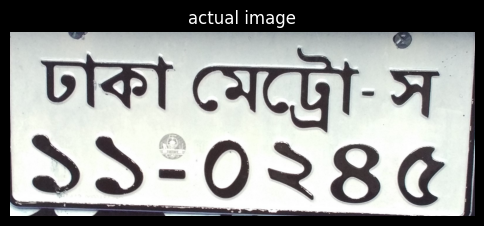

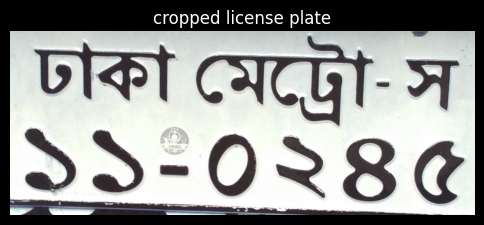

In [103]:
show("actual image", image)
show("cropped license plate",cropped_image)
from IPython.display import display, HTML
display(HTML(f'<h1 style="color: white; font-family: sans-serif;">Extracted Result: {final_text}</h1>'))